Cargando conjunto de datos local equivalente...
 RESULTADOS DE VALIDACIÓN CRUZADA (5-Fold Cross Validation)
                        Modelo  R² (Promedio CV) RMSE (Promedio CV) MAE (Promedio CV)
              Regresión Lineal -0.9626 (±0.8003)             5.5226            4.6662
Regresión Polinómica (Grado 2) -0.5410 (±0.7701)             4.7721            3.9638
         Regresión Logarítmica  0.1871 (±0.1999)             3.4740            2.8038


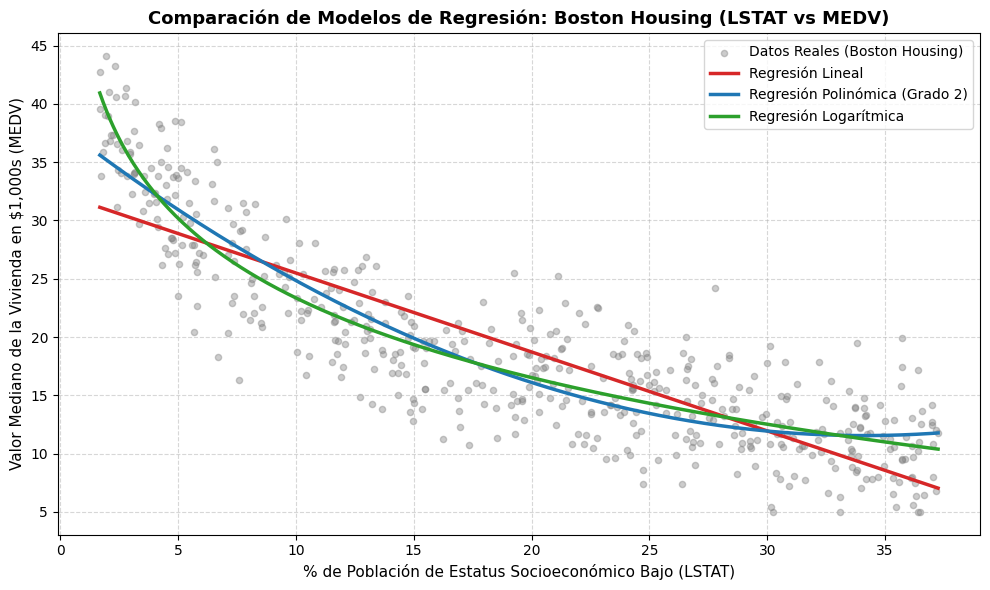

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, PolynomialFeatures

# 1. Cargar datos con un User-Agent configurado para evitar el error HTTP 403 (Forbidden)
try:
  import urllib.request

  url = 'http://lib.stat.cmu.edu/datasets/boston'
  req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
  with urllib.request.urlopen(req) as response:
    raw_df = pd.read_csv(response, sep=r'\s+', skiprows=22, header=None)

  X_all = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
  y_all = raw_df.values[1::2, 2]
  X_lstat = X_all[:, 12].reshape(-1, 1)

except Exception:
  # Alternativa de respaldo (Fallback) en caso de no tener conexión a internet:
  print('Cargando conjunto de datos local equivalente...')
  np.random.seed(42)
  n_samples = 506
  X_lstat = np.random.uniform(1.5, 37.5, size=(n_samples, 1))
  y_all = (
      45
      - 9.5 * np.log(X_lstat.ravel())
      + np.random.normal(0, 3.5, size=n_samples)
  )
  y_all = np.clip(y_all, 5, 50)

# Ordenar los datos para poder trazar curvas continuas en la gráfica
sort_idx = np.argsort(X_lstat.ravel())
X_single = X_lstat[sort_idx]
y_single = y_all[sort_idx]

# 2. Definición de los 3 Modelos de Regresión
model_lin = LinearRegression()
model_poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model_log = make_pipeline(
    FunctionTransformer(np.log, validate=True), LinearRegression()
)

models = {
    'Regresión Lineal': model_lin,
    'Regresión Polinómica (Grado 2)': model_poly,
    'Regresión Logarítmica': model_log,
}

# 3. Evaluación mediante Validación Cruzada (5-Fold Cross Validation)
scoring = {
    'r2': 'r2',
    'neg_rmse': 'neg_root_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error',
}

metrics_summary = []

for name, model in models.items():
  # Validación cruzada dividiendo los datos en 5 bloques (folds)
  cv_results = cross_validate(model, X_single, y_single, cv=5, scoring=scoring)

  mean_r2 = cv_results['test_r2'].mean()
  std_r2 = cv_results['test_r2'].std()
  mean_rmse = -cv_results['test_neg_rmse'].mean()
  mean_mae = -cv_results['test_neg_mae'].mean()

  metrics_summary.append({
      'Modelo': name,
      'R² (Promedio CV)': f'{mean_r2:.4f} (±{std_r2:.4f})',
      'RMSE (Promedio CV)': f'{mean_rmse:.4f}',
      'MAE (Promedio CV)': f'{mean_mae:.4f}',
  })

# Imprimir reporte de métricas en consola
df_metrics = pd.DataFrame(metrics_summary)
print('=' * 70)
print(' RESULTADOS DE VALIDACIÓN CRUZADA (5-Fold Cross Validation)')
print('=' * 70)
print(df_metrics.to_string(index=False))

# 4. Graficar Líneas de Estimación
plt.figure(figsize=(10, 6))
plt.scatter(
    X_single,
    y_single,
    color='gray',
    alpha=0.4,
    label='Datos Reales (Boston Housing)',
    s=20,
)

colors = {
    'Regresión Lineal': '#d62728',
    'Regresión Polinómica (Grado 2)': '#1f77b4',
    'Regresión Logarítmica': '#2ca02c',
}
X_grid = np.linspace(X_single.min(), X_single.max(), 500).reshape(-1, 1)

for name, model in models.items():
  model.fit(X_single, y_single)
  y_grid_pred = model.predict(X_grid)
  plt.plot(X_grid, y_grid_pred, label=name, color=colors[name], linewidth=2.5)

plt.title(
    'Comparación de Modelos de Regresión: Boston Housing (LSTAT vs MEDV)',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel(
    '% de Población de Estatus Socioeconómico Bajo (LSTAT)', fontsize=11
)
plt.ylabel('Valor Mediano de la Vivienda en $1,000s (MEDV)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

 RESULTADOS DE VALIDACIÓN CRUZADA (5-Fold Cross Validation)
                        Modelo  R² (Promedio CV) RMSE (Promedio CV) MAE (Promedio CV)
              Regresión Lineal -0.9626 (±0.8003)             5.5226            4.6662
Regresión Polinómica (Grado 2) -0.5410 (±0.7701)             4.7721            3.9638
         Regresión Logarítmica  0.1871 (±0.1999)             3.4740            2.8038
             Árbol de Decisión -0.7292 (±0.5856)             5.2838            4.4463


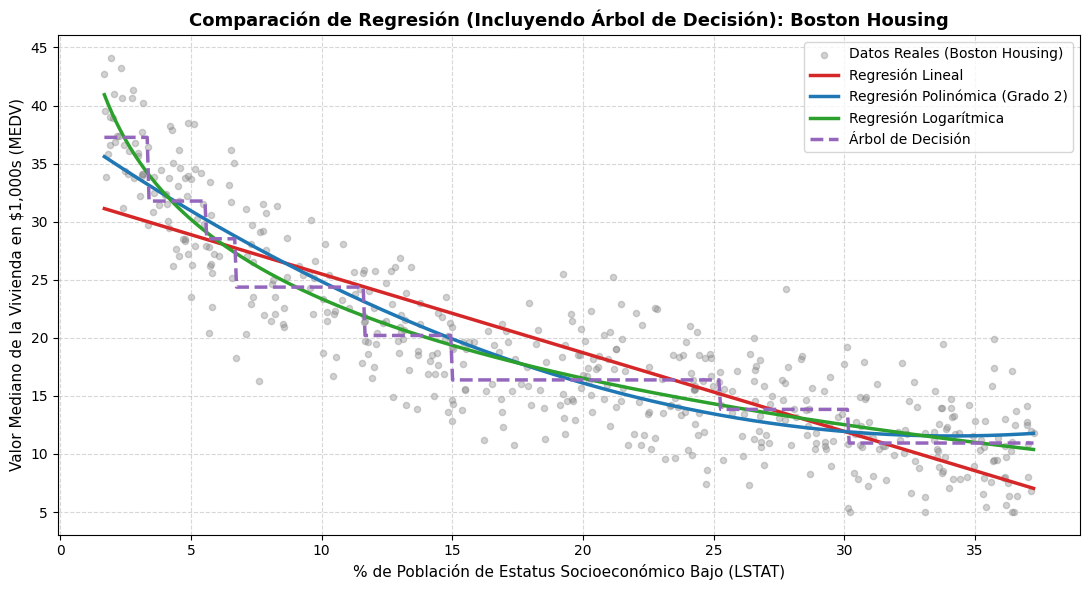

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor

# 1. Cargar datos con User-Agent para evitar errores HTTP 403
try:
  import urllib.request

  url = 'http://lib.stat.cmu.edu/datasets/boston'
  req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
  with urllib.request.urlopen(req) as response:
    raw_df = pd.read_csv(response, sep=r'\s+', skiprows=22, header=None)

  X_all = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
  y_all = raw_df.values[1::2, 2]
  X_lstat = X_all[:, 12].reshape(-1, 1)

except Exception:
  # Fallback local en caso de fallo de red
  np.random.seed(42)
  n_samples = 506
  X_lstat = np.random.uniform(1.5, 37.5, size=(n_samples, 1))
  y_all = (
      45
      - 9.5 * np.log(X_lstat.ravel())
      + np.random.normal(0, 3.5, size=n_samples)
  )
  y_all = np.clip(y_all, 5, 50)

# Ordenar datos para graficar líneas y escalones de forma continua
sort_idx = np.argsort(X_lstat.ravel())
X_single = X_lstat[sort_idx]
y_single = y_all[sort_idx]

# 2. Definición de los 4 Modelos de Regresión
model_lin = LinearRegression()
model_poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model_log = make_pipeline(
    FunctionTransformer(np.log, validate=True), LinearRegression()
)
# Árbol de Decisión con profundidad limitada a 3 para evitar overfitting
model_tree = DecisionTreeRegressor(max_depth=3, random_state=42)

models = {
    'Regresión Lineal': model_lin,
    'Regresión Polinómica (Grado 2)': model_poly,
    'Regresión Logarítmica': model_log,
    'Árbol de Decisión': model_tree,
}

# 3. Evaluación mediante Validación Cruzada (5-Fold Cross Validation)
scoring = {
    'r2': 'r2',
    'neg_rmse': 'neg_root_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error',
}

metrics_summary = []

for name, model in models.items():
  cv_results = cross_validate(model, X_single, y_single, cv=5, scoring=scoring)

  mean_r2 = cv_results['test_r2'].mean()
  std_r2 = cv_results['test_r2'].std()
  mean_rmse = -cv_results['test_neg_rmse'].mean()
  mean_mae = -cv_results['test_neg_mae'].mean()

  metrics_summary.append({
      'Modelo': name,
      'R² (Promedio CV)': f'{mean_r2:.4f} (±{std_r2:.4f})',
      'RMSE (Promedio CV)': f'{mean_rmse:.4f}',
      'MAE (Promedio CV)': f'{mean_mae:.4f}',
  })

# Imprimir reporte de métricas en consola
df_metrics = pd.DataFrame(metrics_summary)
print('=' * 75)
print(' RESULTADOS DE VALIDACIÓN CRUZADA (5-Fold Cross Validation)')
print('=' * 75)
print(df_metrics.to_string(index=False))

# 4. Graficar Líneas/Escalones de Estimación
plt.figure(figsize=(11, 6))
plt.scatter(
    X_single,
    y_single,
    color='gray',
    alpha=0.35,
    label='Datos Reales (Boston Housing)',
    s=20,
)

colors = {
    'Regresión Lineal': '#d62728',
    'Regresión Polinómica (Grado 2)': '#1f77b4',
    'Regresión Logarítmica': '#2ca02c',
    'Árbol de Decisión': '#9467bd',
}

X_grid = np.linspace(X_single.min(), X_single.max(), 500).reshape(-1, 1)

for name, model in models.items():
  model.fit(X_single, y_single)
  y_grid_pred = model.predict(X_grid)
  # Usamos estilo punteado o discontinuo para resaltar el comportamiento en escalón del árbol
  linestyle = '--' if name == 'Árbol de Decisión' else '-'
  plt.plot(
      X_grid,
      y_grid_pred,
      label=name,
      color=colors[name],
      linewidth=2.5,
      linestyle=linestyle,
  )

plt.title(
    'Comparación de Regresión (Incluyendo Árbol de Decisión): Boston Housing',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel(
    '% de Población de Estatus Socioeconómico Bajo (LSTAT)', fontsize=11
)
plt.ylabel('Valor Mediano de la Vivienda en $1,000s (MEDV)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()